In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from IPython.display import display
print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
#read data from files
ds = pd.read_csv("collegiate_athlete_injury_dataset.csv")
#print categories
ds_final = pd.get_dummies(ds, columns=['Position'], prefix='Pos')
print(ds_final.columns)
display(ds_final.head())
#shows top of the file, change int parameter within "head()" to see more
#display(ds.tail())
#shows bottom of the file, just to make sure data didnt get cut off

Index(['Athlete_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg',
       'Training_Intensity', 'Training_Hours_Per_Week',
       'Recovery_Days_Per_Week', 'Match_Count_Per_Week',
       'Rest_Between_Events_Days', 'Fatigue_Score', 'Performance_Score',
       'Team_Contribution_Score', 'Load_Balance_Score', 'ACL_Risk_Score',
       'Injury_Indicator', 'Pos_Center', 'Pos_Forward', 'Pos_Guard'],
      dtype='object')


,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator,Pos_Center,Pos_Forward,Pos_Guard
0,A001,24,Female,195,99,2,13,2,3,1,1,99,58,100,4,0,True,False,False
1,A002,21,Male,192,65,8,14,1,3,1,4,55,63,83,73,0,False,True,False
2,A003,22,Male,163,83,8,8,2,1,3,6,58,62,100,62,0,False,False,True
3,A004,24,Female,192,90,1,13,1,1,1,7,82,74,78,51,0,False,False,True
4,A005,20,Female,173,79,3,9,1,2,1,2,90,51,83,49,0,True,False,False


In [3]:
print(ds.isnull().sum())
#make sure data isn't missing in any columns

Athlete_ID                  0
Age                         0
Gender                      0
Height_cm                   0
Weight_kg                   0
Position                    0
Training_Intensity          0
Training_Hours_Per_Week     0
Recovery_Days_Per_Week      0
Match_Count_Per_Week        0
Rest_Between_Events_Days    0
Fatigue_Score               0
Performance_Score           0
Team_Contribution_Score     0
Load_Balance_Score          0
ACL_Risk_Score              0
Injury_Indicator            0
dtype: int64


In [4]:
ds.describe()
#Statistical summary of all values

,Age,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator
count,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.170000,180.805000,77.475000,5.10500,11.315000,1.985000,2.385000,1.975000,4.920000,74.465000,72.630000,93.395000,46.470000,0.070000
std,2.002787,11.529598,12.440789,2.49904,4.438952,0.811212,1.154748,0.817137,2.560543,14.636939,14.432762,8.660485,18.943956,0.255787
min,18.000000,160.000000,55.000000,1.00000,5.000000,1.000000,1.000000,1.000000,1.000000,50.000000,50.000000,62.000000,2.000000,0.000000
25%,19.000000,171.000000,67.000000,3.00000,7.000000,1.000000,1.000000,1.000000,3.000000,62.000000,60.750000,89.000000,33.000000,0.000000
50%,21.000000,182.500000,77.500000,5.00000,11.000000,2.000000,2.000000,2.000000,5.000000,74.000000,72.000000,98.000000,45.000000,0.000000
75%,23.000000,191.000000,89.000000,7.00000,15.000000,3.000000,3.000000,3.000000,7.000000,86.250000,85.000000,100.000000,60.000000,0.000000
max,24.000000,199.000000,99.000000,9.00000,19.000000,3.000000,4.000000,3.000000,9.000000,99.000000,99.000000,100.000000,100.000000,1.000000


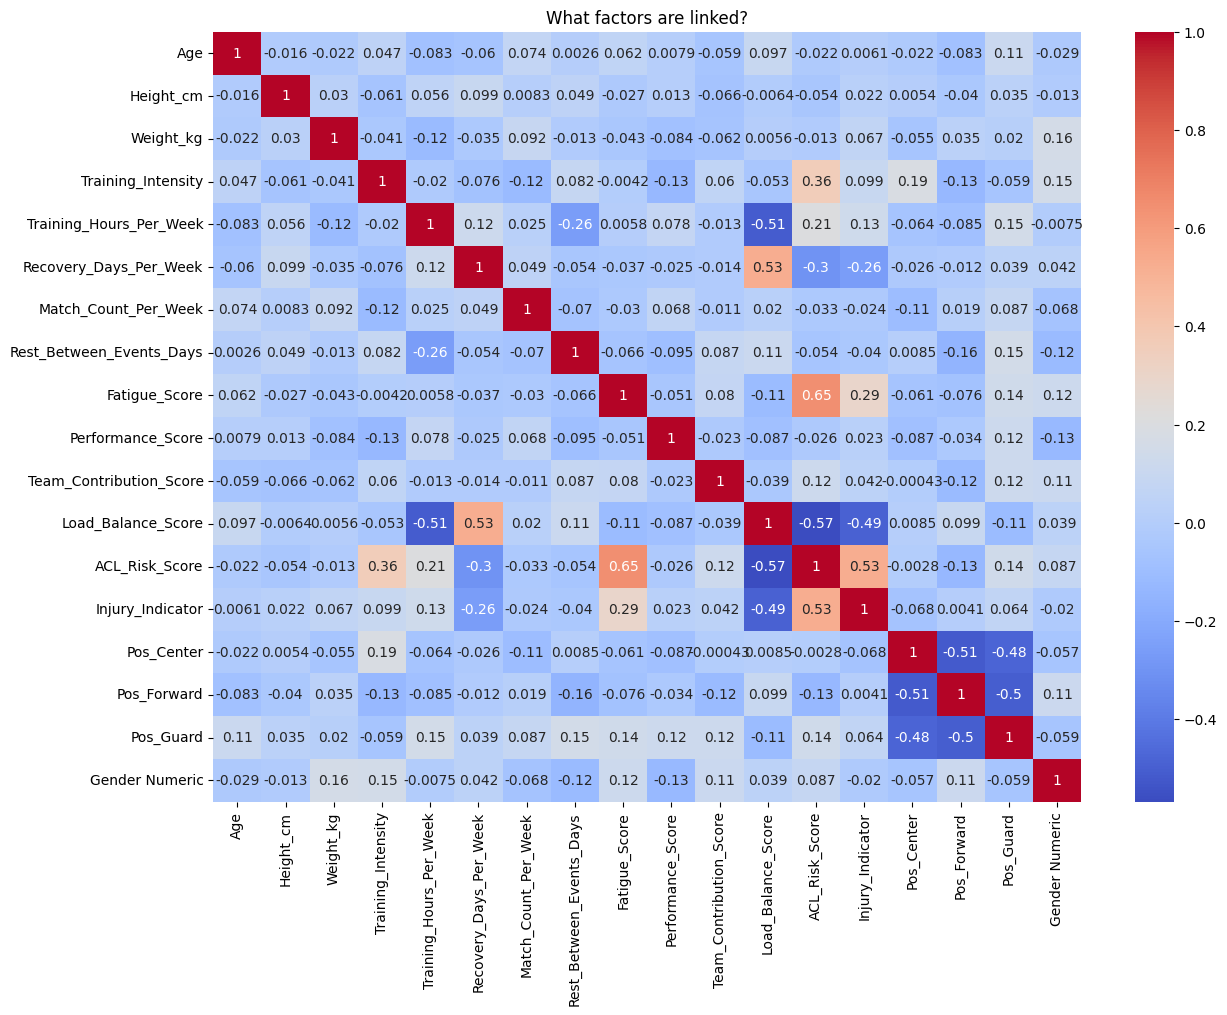

In [5]:
# This shows which factors have the strongest link to injury
plt.figure(figsize=(14, 10))

#Converting Gender to numeric data
ds_final['Gender Numeric'] = ds_final['Gender'].map({'Female': 0, 'Male': 1})



#ignores columns with text based responses
correlation_matrix = ds_final.corr(numeric_only=True)

#red = high cor. 
#blue = low cor.
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

#chart title
plt.title('What factors are linked?')

#print graph
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#features (X) and what you want to predict (y)
#'ds_final' because it has our encoded positions
X = ds_final.drop(['Athlete_ID', 'Gender', 'Injury_Indicator'], axis=1)
y = ds_final['Injury_Indicator']

# 2. Split data: 80% for learning, 20% for testing the AI's "exam"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the model
# Adding class_weight='balanced' tells the AI to care more about the rare injury cases
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 4. Check the results
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 95.00%

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        38
           1       0.00      0.00      0.00         2

    accuracy                           0.95        40
   macro avg       0.47      0.50      0.49        40
weighted avg       0.90      0.95      0.93        40



/Users/sriramcj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sriramcj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sriramcj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

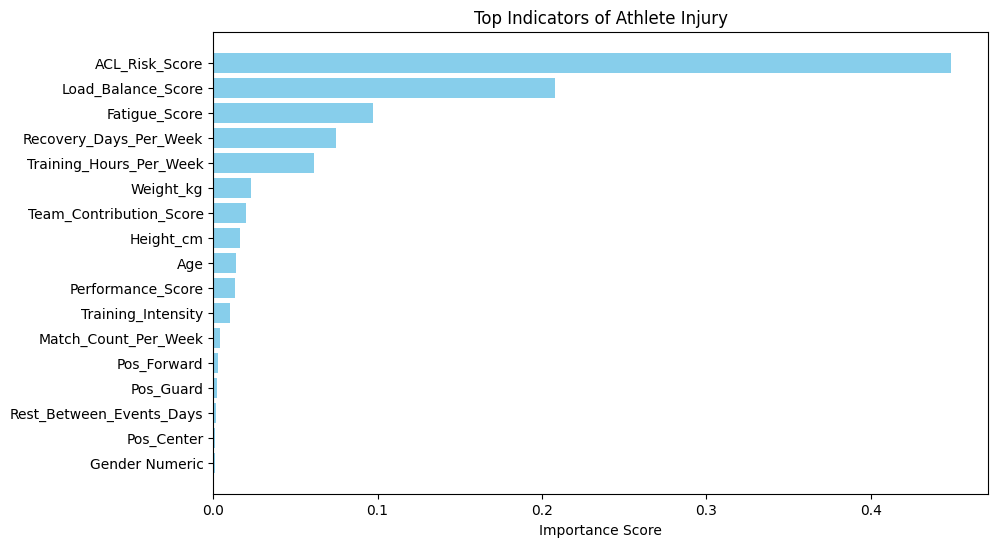

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the importance scores from your trained model
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top Indicators of Athlete Injury')
plt.gca().invert_yaxis()
plt.show()

In [17]:
import numpy as np

# 1. Create a fake athlete (Match the columns in your X)
# Order: Age, Height, Weight, Avg_Practice_Intensity, Fatigue_Score, 
#        Recovery_Days, ACL_Risk_Score, Gender_Numeric, Pos_Center, Pos_Forward, Pos_Guard
fake_athlete = pd.DataFrame(0, index=[0], columns=X.columns)
fake_athlete['Age'] = 21
fake_athlete['Height_cm'] = 185
fake_athlete['Weight_kg'] = 85
fake_athlete['Training_Intensity'] = 9.5
fake_athlete['Training_Hours_Per_Week'] = 18.0 # Corrected Name
fake_athlete['Fatigue_Score'] = 9.0
fake_athlete['Recovery_Days_Per_Week'] = 1
fake_athlete['ACL_Risk_Score'] = 0.85
fake_athlete['Gender Numeric'] = 1  # Male
fake_athlete['Pos_Forward'] = 1

# 2. Ask the model to predict
prediction = model.predict(fake_athlete)
probability = model.predict_proba(fake_athlete)

# 3. Print the Result
status = "Injured" if prediction[0] == 1 else "Healthy"
print(f"Prediction: {status}")
print(f"Probability of Injury: {probability[0][1] * 100:.2f}%")

Prediction: Healthy
Probability of Injury: 25.00%
